# SPHEREx Self-calibration Dev

In [1]:
import glob
import os
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import sys 
import gc 

import importlib
# sys.path.insert(0, '/home/thomasli/spherex/selfcal')
from SelfCal import EuclidUtility
from SelfCal import WCSHelper
from SelfCal import MakeMap
from SelfCal import MapHelper
importlib.reload(MapHelper)

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial

from SelfCal.MapHelper import bit_to_bool, make_weight, find_outliers, map_pixels,compute_chunk_contrib
from SelfCal.WCSHelper import load_from_fits, save_to_fits, find_optimal_frame
from SelfCal import PipelineWrapper


In [ ]:
from SelfCal.SPHERExUtility import make_fiducial_chunk_mask, load_calibration, make_fiducial_chunk_map, extract_spherex_channel_edges, make_spherex_chunk_map, interp_2d_vertical

In [3]:
from SelfCal.MakeMap import *
from SelfCal.MapHelper import *

In [4]:
detector = 1

det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')

In [5]:
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17, oversample_factor=4)
chunk_valid_mask = make_fiducial_chunk_mask([4],  num_subchannels=10, num_channels=17)
det_valid_mask = chunk_valid_mask[chunk_map]

Fitting LVF parameters...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:06<00:00, 26.79it/s]


Making chunk map...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:30<00:00,  5.65it/s]


### Test Reproject

In [31]:
detector = 4
config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{detector}_3p1arcsec'
config['resolution_arcsec'] = 3.1

rr = PipelineWrapper.Reprojector(config)
rr.define_reference(padding_pixels=100, use_ext=[1])

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits
Mosaic shape: (17404, 18268)
Mosaic WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 275.01757761362 68.760596866799 
CRPIX : 9718.8398450881 8463.2097864339 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00086111111111111 0.00086111111111111 
NAXIS : 18268  17404


In [32]:
exposure_list = glob.glob(f'/mnt/md127/SPHEREx/reproc_data/deep_north/*/*/*/*D{detector}*.fits')


In [36]:
reproj_func = 'interp'
file_path = exposure_list[0]
exp_idx = 0
det_idx = 0
sci_ext = 1
dq_ext = 2
ref_wcs = rr.ref_wcs
sub_width = 6305
output_dir = '/home/thomasli/spherex/selfcal/test_dir/'
replace_existing = True
reproject_kwargs = {}

# Save to HDF5
output_file = os.path.join(output_dir, f'exp_{exp_idx:04d}_det_{det_idx:02d}.h5')

reproj_func_dict = {'exact': reproject_exact, 'interp': reproject_interp, 'adaptive': reproject_adaptive}

with fits.open(file_path) as hdul:
    det_data = hdul[sci_ext].data
    det_width = np.shape(det_data)[-1]
    det_header = hdul[sci_ext].header
    det_header_str = det_header.tostring().encode('utf-8')
    det_wcs = WCS(det_header)
    det_bitmask = hdul[dq_ext].data

# Map detector center to world, then to reference frame pixels 
det_center = [det_data.shape[0] / 2.0, det_data.shape[1] / 2.0]           
skycoord = det_wcs.pixel_to_world(det_center[1], det_center[0])
ref_det_center = np.array(ref_wcs.world_to_pixel(skycoord))

# Define sub-frame boundaries in the reference frame
ref_x_min = int(ref_det_center[0] - sub_width // 2)
ref_x_max = ref_x_min + sub_width
ref_y_min = int(ref_det_center[1] - sub_width // 2)
ref_y_max = ref_y_min + sub_width

# Create WCS for the sub-frame
sub_wcs = ref_wcs.deepcopy()
sub_wcs.wcs.crpix[0] -= ref_x_min # Adjust CRPIX for the sub-frame origin
sub_wcs.wcs.crpix[1] -= ref_y_min
sub_header_str = sub_wcs.to_header().tostring().encode('utf-8') 

# Perform reprojection
sub_data, sub_foot = reproj_func_dict[reproj_func](
    (det_data, det_wcs), 
    sub_wcs, 
    shape_out=(sub_width, sub_width), 
    **reproject_kwargs
)

# Process detector auxiliary data
det_expanded_mask = bit_to_bool(det_bitmask, expand_bits=True)
det_xmesh, det_ymesh = np.meshgrid(np.arange(det_width), np.arange(det_width))
det_aux = np.stack((det_xmesh, det_ymesh, *det_expanded_mask), axis=0)
sub_aux, _ = reproject_interp(
    (det_aux, det_wcs), 
    sub_wcs, 
    shape_out=(sub_width, sub_width), 
    order='bilinear',
)
sub_mapping = sub_aux[0:2] # x, y
sub_expanded_mask_float = sub_aux[2:]
sub_expanded_mask_bool = sub_expanded_mask_float > 0.01
sub_bitmask = bool_to_bit(sub_expanded_mask_bool)


In [39]:
with h5py.File(output_file, 'w', libver='latest') as hf:
    # CONFIG: Zstd + Shuffle
    # Zstd creates smaller files than Gzip, relieving your I/O bottleneck.
    # **hdf5plugin.Zstd() automatically handles the filter setup.
    comp_args = {
        **hdf5plugin.Zstd(clevel=5), 
        'shuffle': True,
        'track_times': False
    }

    # 1. Save Data
    hf.create_dataset('sub_data', data=sub_data, dtype=np.float32, chunks=sub_data.shape, **comp_args)
    hf.create_dataset('sub_foot', data=sub_foot, dtype=np.float16, chunks=sub_foot.shape, **comp_args)
    hf.create_dataset('sub_bitmask', data=sub_bitmask, dtype=np.int32, chunks=sub_bitmask.shape, **comp_args)
    hf.create_dataset('sub_mapping', data=sub_mapping, dtype=np.float32, chunks=sub_mapping.shape, **comp_args)
    
    # 2. Save Metadata as Attributes
    hf.attrs['sub_header'] = sub_header_str
    hf.attrs['det_header'] = det_header_str
    hf.attrs['file_path'] = file_path
    hf.attrs['ref_coords'] = np.array([ref_y_min, ref_y_max, ref_x_min, ref_x_max], dtype=np.int32)

### Test Coadd

In [6]:
importlib.reload(PipelineWrapper)
importlib.reload(MakeMap)
from SelfCal import PipelineWrapper

In [8]:
detector = 4
config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{detector}_3p1arcsec'
config['resolution_arcsec'] = 3.1

In [61]:
cc = PipelineWrapper.Calibrator(config)


cc.reproj_list = cc.reproj_list[0:1200]
cc.exp_idx_list = cc.exp_idx_list[0:1200]
cc.det_idx_list = cc.det_idx_list[0:1200]

cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=False, 
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40, 
    outlier_thresh=10.0,
    ignore_list=[],
    oversample_factor=4,
    batch_size=10
    )

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2465/2465 [00:00<00:00, 650617.29it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits
Processing 1200 items in 120 batches (Batch Size: 10)...


Building A, b matrix: 100%|███████████████████████████████████████████████████████████████████████████████████████| 120/120 [09:55<00:00,  4.96s/it]


In [9]:
mm = PipelineWrapper.Mosaicker(config)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2798/2798 [00:00<00:00, 667861.52it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits


In [10]:
mm.reproj_list = mm.reproj_list[0:1200]

In [13]:
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=True, 
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40,
    make_std_map=False, 
    apply_sigma_clipping=False, 
    sigma=1.0,
    ignore_list=[21],
    oversample_factor=4,
    det_offset_func=partial_make_offset_map,
    batch_size=20
)


Processing 1200 files in 60 batches (Batch Size: 20)...


Computing mean map: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 60/60 [13:43<00:00, 13.72s/it]


In [42]:
maps.keys()

dict_keys(['mean_map', 'mean_weight', 'std_map', 'std_weight', 'sc_mean_map', 'sc_mean_weight'])

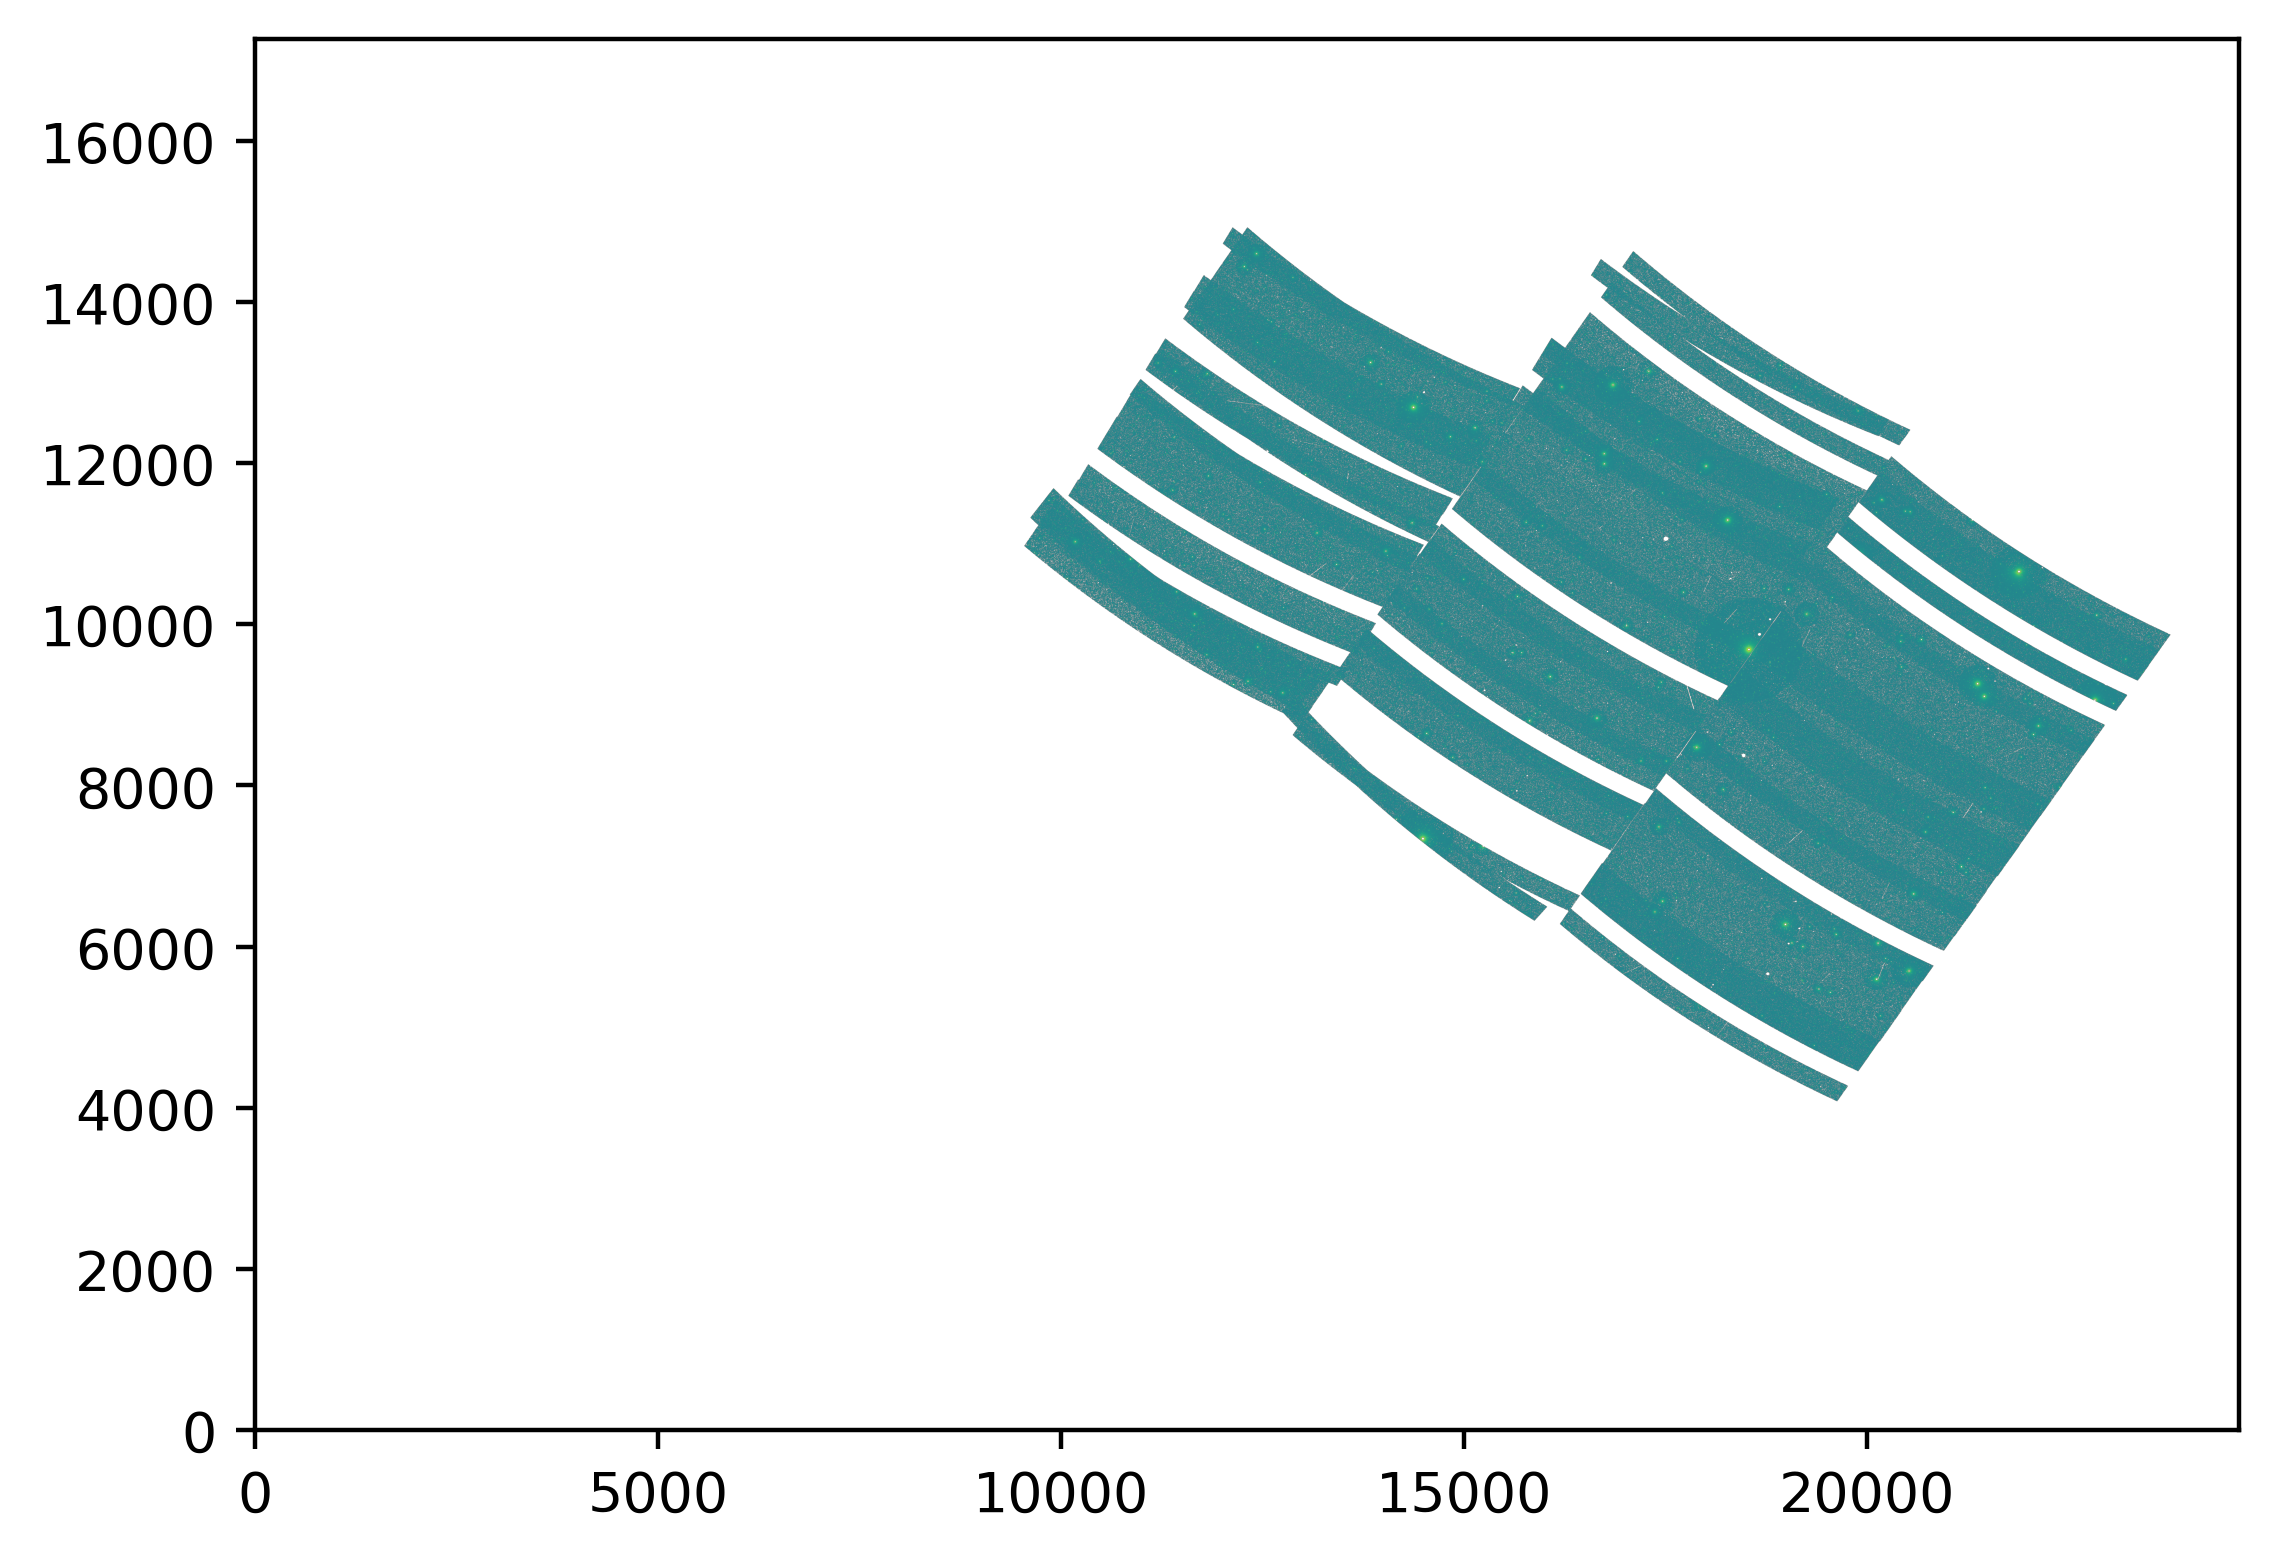

In [48]:
plt.imshow(maps['mean_map'], norm=LogNorm(), origin='lower')

In [ ]:
channel_edges = [0.87, 1.0]
chunk_map = make_spherex_chunk_map(detector, det_BC, fine_edges=channel_edges)
chunk_valid_mask = channel_edges==1

In [ ]:
from SelfCal.MakeMap import _prep_subframe, load_reproj_file

In [40]:
reproj_list = sorted(glob.glob('/data3/thomasli/selfcal/outputs/nep_det4_3p1arcsec/reprojected/*.h5'))
reproj_sample = load_reproj_file('/home/thomasli/spherex/selfcal/test_dir/exp_0000_det_00.h5', fields=['sub_data', 'sub_header', 'det_header', 
                                                         'ref_coords', 'file_path', 'sub_bitmask', 'sub_mapping', 'sub_foot'])

In [41]:
reproj_sample

{'sub_data': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(6305, 6305), dtype=float32),
 'sub_header': "WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =      3955.8398450881 / Pixel coordinate of reference point            CRPIX2  =      1920.2097864339 / Pixel coordinate of reference point            CDELT1  = -0.00086111111111111 / [deg] Coordinate increment at reference point  CDELT2  =  0.00086111111111111 / [deg] Coordinate increment at reference point  CUNIT1  = 'deg'                / Units of coordinate increment and value        CUNIT2  = 'deg'                / Units of coordinate increment and value        CTYPE1  = 'RA---TAN'           / Right ascension, gnomonic projection           CTYPE

In [28]:
with h5py.File(reproj_list[100], 'r') as f:
    print(f.keys())

<KeysViewHDF5 []>


In [19]:
# Get bytesizes of keys in the reproj file
total_bytes = 0
for key in reproj_sample.keys():
    if isinstance(reproj_sample[key], np.ndarray):
        print(f"{key}: {reproj_sample[key].nbytes / 1e6} MB")
        total_bytes += reproj_sample[key].nbytes

print(f"Total size: {total_bytes / 1e6} MB")

Total size: 0.0 MB


In [28]:
# Get bytesizes of keys in the reproj file
total_bytes = 0
for key in reproj_sample.keys():
    if isinstance(reproj_sample[key], np.ndarray):
        print(f"{key}: {reproj_sample[key].nbytes / 1e6} MB")
        total_bytes += reproj_sample[key].nbytes
print(f"Total size: {total_bytes / 1e6} MB")

sub_data: 158.961664 MB
ref_coords: 1.6e-05 MB
sub_bitmask: 158.961664 MB
sub_mapping: 317.923328 MB
sub_foot: 79.480832 MB
Total size: 715.327504 MB


### _prep_subframe

In [7]:
importlib.reload(MakeMap)
importlib.reload(MapHelper)
from SelfCal.MakeMap import _prep_subframe
from SelfCal.MapHelper import *

In [12]:
def make_spherex_offset_map(chunk_map, chunk_offset, chunk_valid_mask, lvf_params):
    R = lvf_params['R']
    xc, yc = lvf_params['xc'], lvf_params['yc']

    edge_valid_mask = chunk_valid_mask[1:].astype(bool) | chunk_valid_mask[:-1].astype(bool)
    valid_R = R[edge_valid_mask]
    spl = mean_preserving_spline(x_edge=valid_R, y_mean=chunk_offset[chunk_valid_mask.astype(bool)])

    h, w = np.shape(chunk_map)
    oversample_factor = h // 2040
    
    x_vec = (np.arange(w) / oversample_factor) - xc
    y_vec = (np.arange(h) / oversample_factor) - yc
    r_mesh = np.sqrt(x_vec**2 + y_vec[:, None]**2)
    
    offset_map = spl(r_mesh)
    return offset_map
    
partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)

In [19]:
R = lvf_params['R']
edge_valid_mask = chunk_valid_mask[1:].astype(bool) | chunk_valid_mask[:-1].astype(bool)
valid_R = R[edge_valid_mask]
spl = mean_preserving_spline(x_edge=valid_R, y_mean=chunk_offset[chunk_valid_mask.astype(bool)])
out_shape = np.shape(chunk_map)
oversample_factor = out_shape[0]//2040

In [32]:
foo = make_det_offset(chunk_map, chunk_offset)

In [15]:
ref_coords, sub_data, sub_weight, chunk_contrib = _prep_subframe(
    file = '/mnt/md127/thomasli/selfcal/outputs/nep_det3_3p1arcsec/reprojected/exp_0000_det_00.h5',
    exp_idx = 0,
    det_idx = 0,
    chunk_map = chunk_map,
    det_valid_mask = det_valid_mask,
    apply_weight = False,
    apply_mask = True,
    chunk_offset = 2*np.arange(len(chunk_valid_mask))/171,
    ignore_list = [21],
    valid_threshold = 0.99,
    for_lsqr = False,#True,
    det_offset_func = partial_make_offset_map,
    oversample_factor = 4
    )

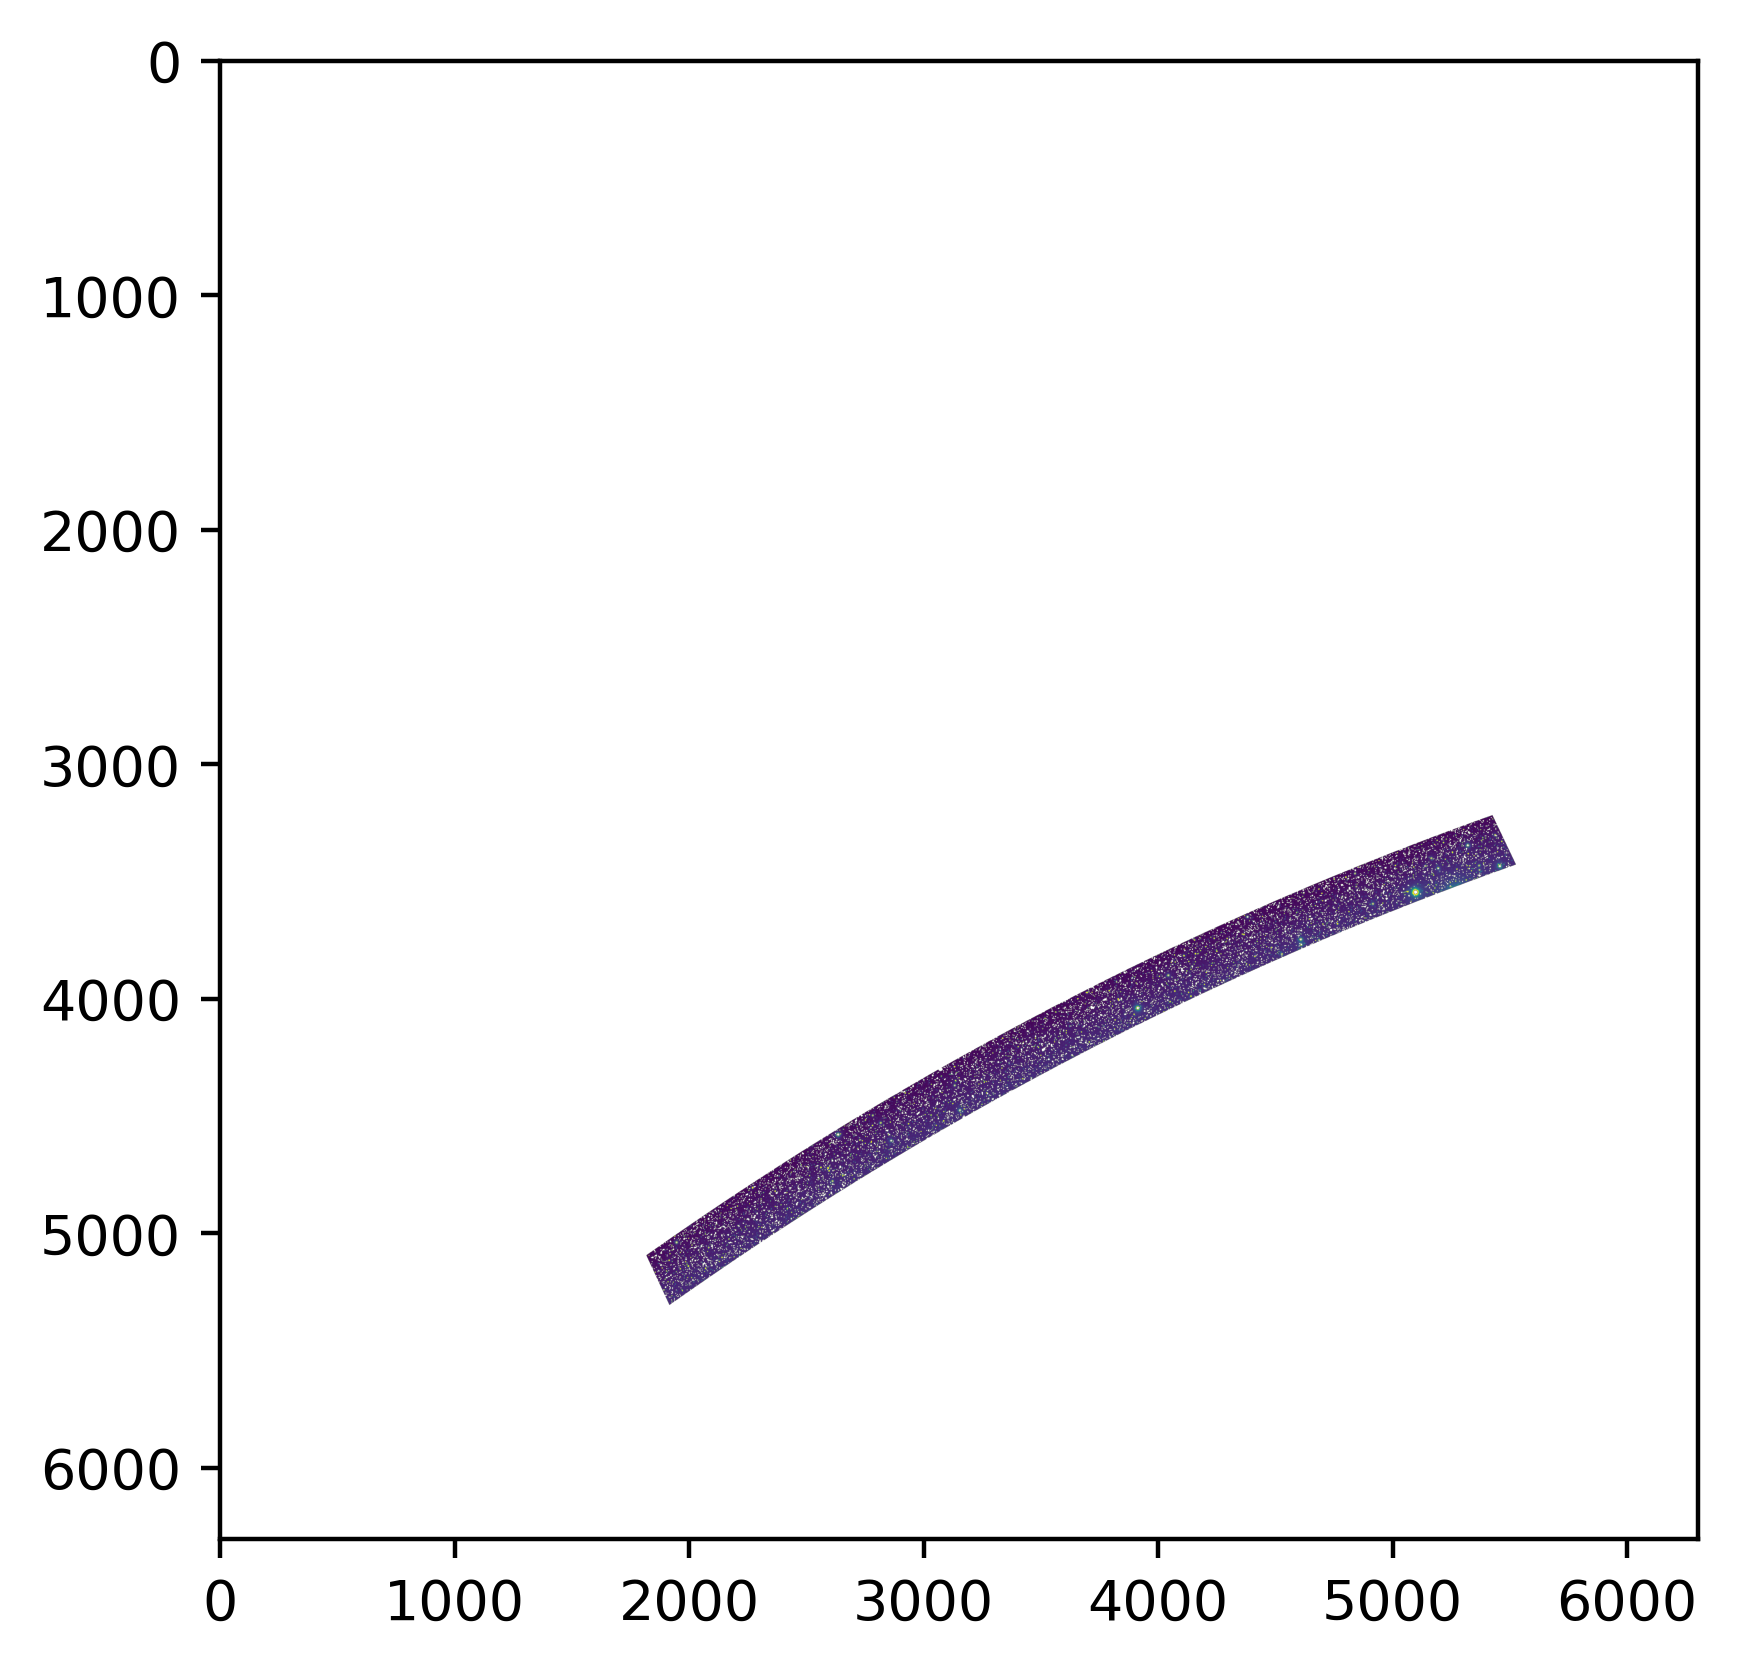

In [84]:
plt.imshow(sub_data, vmin=np.nanpercentile(sub_data, 1), vmax=np.nanpercentile(sub_data, 99))

In [65]:
file = '/home/thomasli/spherex/selfcal/test_dir/exp_0000_det_00.h5'
exp_idx = 0
det_idx = 0
chunk_map = chunk_map
det_valid_mask = det_valid_mask
apply_weight = False
apply_mask = True
chunk_offset = None#1*np.arange(len(chunk_valid_mask))/171
ignore_list = [21]
valid_threshold = 0.99
for_lsqr = True
make_det_offset = None#partial_make_offset_map

In [ ]:
fields=['sub_data', 'ref_coords', 'sub_mapping']
if apply_mask:
    fields.append('sub_bitmask')
result = load_reproj_file(file, fields=fields)

sub_data = result['sub_data']
oversample_factor = 4
ref_coords = result['ref_coords']
sub_fullmask = np.ones_like(sub_data, dtype=bool)
sub_mapping = result['sub_mapping']

if 'sub_bitmask' in result:
    # invert=True: 1 = Good pixel, 0 = Bad pixel
    sub_boolmask = bit_to_bool(result['sub_bitmask'], ignore_list, invert=True)
    sub_fullmask &= sub_boolmask

if (chunk_map is not None) or (chunk_offset is not None) or for_lsqr:
    sub_mapping_flat = sub_mapping.reshape(2, np.prod(sub_mapping.shape[1:]))
    sub_mapping_flat_scaled = sub_mapping_flat * oversample_factor
    det_to_sub_flat_matrix = make_linear_interp_matrix(sub_mapping_flat_scaled[::-1], input_shape=np.shape(chunk_map))

if chunk_offset is not None:
    if make_det_offset:
        det_offset = make_det_offset(chunk_map, chunk_offset)
    else:
        det_offset = chunk_to_det(chunk_map, chunk_data=chunk_offset)
    sub_offset = det_to_sub(det_offset, interp_matrix=det_to_sub_flat_matrix)
    sub_data -= sub_offset

if det_valid_mask is not None:
    sub_valid_frac = det_to_sub(det_valid_mask, interp_matrix=det_to_sub_flat_matrix)
    sub_valid_mask = sub_valid_frac > valid_threshold
    sub_fullmask &= sub_valid_mask

sub_data[~sub_fullmask] = np.nan

sub_weight = make_weight(sub_data) if apply_weight else np.ones_like(sub_data, dtype=np.float32)

chunk_contrib = None
if for_lsqr:
    chunk_contrib = compute_chunk_contrib(chunk_map, det_to_sub_flat_matrix)


In [73]:
sub_mapping.shape

(2, 6305, 6305)

In [ ]:
plt.imshow(chunk_contrib[1].toarray().reshape(sub_data.shape))

In [ ]:
interp_matrix = det_to_sub_flat_matrix
chunk_map_flat = chunk_map.ravel()
cols = chunk_map_flat
rows = np.arange(len(chunk_map_flat))
data = np.ones_like(cols, dtype=np.float32)

total_rows = len(chunk_map_flat)
total_cols = np.max(chunk_map_flat)+1
chunk_map_parsed_old = csr_matrix((data, (rows, cols)), shape=(total_rows, total_cols))

In [ ]:
from scipy.sparse import csc_matrix, csr_matrix

In [ ]:
chunk_map_flat = chunk_map.ravel()

total_rows = chunk_map_flat.size
total_cols = chunk_map_flat.max() + 1
indptr = np.arange(total_rows + 1)
indices = chunk_map_flat
data = np.ones(total_rows, dtype=np.float32)

chunk_map_parsed = csr_matrix((data, indices, indptr), shape=(total_rows, total_cols))

In [ ]:
a = det_to_sub_flat_matrix.tocsc()

In [ ]:
det_to_sub_flat_matrix

In [ ]:
chunk_map_parsed.tocsc()

In [ ]:
chunk_contrib = (det_to_sub_flat_matrix @ chunk_map_parsed).T

In [ ]:
chunk_contrib = (chunk_map_parsed.T @ det_to_sub_flat_matrix.T)

In [ ]:
edge_valid_mask = chunk_valid_mask[1:].astype(bool) | chunk_valid_mask[:-1].astype(bool)

In [ ]:
chunk_offset = 1*np.arange(len(chunk_valid_mask))/171

In [ ]:
R = lvf_params['R']
valid_R = R[edge_valid_mask]

spl = mean_preserving_spline(x_edge=valid_R, y_mean=chunk_offset[chunk_valid_mask.astype(bool)])

In [ ]:
def make_spherex_offset_map(chunk_map, chunk_offset, chunk_valid_mask, lvf_params):
    R = lvf_params['R']
    edge_valid_mask = chunk_valid_mask[1:].astype(bool) | chunk_valid_mask[:-1].astype(bool)
    valid_R = R[edge_valid_mask]
    spl = mean_preserving_spline(x_edge=valid_R, y_mean=chunk_offset[chunk_valid_mask.astype(bool)])

    out_shape = np.shape(chunk_map)
    oversample_factor = out_shape[0]//2040
    x_mesh, y_mesh = np.meshgrid(np.arange(out_shape[1]*oversample_factor), np.arange(out_shape[0]*oversample_factor))/oversample_factor
    r_mesh = np.sqrt((x_mesh - lvf_params['xc'])**2 + (y_mesh - lvf_params['yc'])**2)
    offset_map = spl(r_mesh)
    return offset_map
    

In [ ]:
over_sample_factor = 4
out_shape = (2040, 2040)

rr = np.sqrt((x_mesh - lvf_params['xc'])**2 + (y_mesh - lvf_params['yc'])**2)
offset_map = spl(rr)

In [ ]:
plt.imshow(offset_map, origin='lower')

### Chunk Map

In [ ]:
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, load_calibration, interpolate_array, make_arc_spline

In [ ]:
detector = 1
det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17, oversample_factor=2)

In [ ]:
plt.imshow(chunk_map)
for i in range(len(lvf_params['R'])):
    spl = make_arc_spline(lvf_params['xc'], lvf_params['yc'], lvf_params['R'][i])
    x_arc = np.linspace(0, 2040, 1000)
    y_arc = spl(x_arc)
    plt.plot(x_arc, y_arc, 'r-', linewidth=0.5, alpha=0.5)
plt.xlim(1450, 1950)
plt.ylim(0, 500)

In [ ]:
# plt.plot(fit_params['edge_index'], fit_params['xc'], '.')

### Correct Offset Map Ringing

In [ ]:
wav_edge = lvf_params['wave_edges']
wav_med = 0.5 * (wav_edge[:-1] + wav_edge[1:])

chunk_offset = 0.5*np.arange(len(chunk_valid_mask))# + 10.0 * np.sin(0.5 * np.arange(len(chunk_valid_mask)))

In [ ]:
chunk_offset[0:160] = 0
chunk_offset[170:] = 0

chunk_valid_mask = np.ones_like(chunk_offset, dtype=bool)
chunk_valid_mask[0:160] = 0
chunk_valid_mask[170:] = 0

In [ ]:
from SelfCal.MapHelper import mean_preserving_spline

In [ ]:
importlib.reload(MapHelper)

In [ ]:
lvf_params['R'][chunk_valid_mask[1:-1]]

In [ ]:
edge_valid_mask = chunk_valid_mask[1:] | chunk_valid_mask[:-1]

In [ ]:
R = lvf_params['R']
valid_R = R[edge_valid_mask]

spl = mean_preserving_spline(x_edge=valid_R, y_mean=chunk_offset[chunk_valid_mask])

In [ ]:
# x = np.linspace(wav_med[0], wav_med[-1], 1000)
# y = spl(x)

# plt.plot(wav_med, chunk_offset[1:-1], ls='None', marker='.', markersize=1)
# plt.plot(x, y, '-', linewidth=0.5)

In [ ]:
out_shape = (2040, 2040)
x_mesh, y_mesh = np.meshgrid(np.arange(out_shape[1]), np.arange(out_shape[0]))

rr = np.sqrt((x_mesh - lvf_params['xc'])**2 + (y_mesh - lvf_params['yc'])**2)
offset_map = spl(rr)

In [ ]:
org_offset_map = interp_2d_vertical(chunk_offset[chunk_map])

In [ ]:
# plt.imshow((org_offset_map*chunk_valid_mask[chunk_map])[100:200, -250:-150], vmin=79.5)

In [ ]:
# plt.imshow((offset_map*chunk_valid_mask[chunk_map])[100:200, -250:-150], vmin=79.5)

### Examine Interpolation Methods

In [ ]:
from SelfCal.SPHERExUtility import interp_1d, parse_bin

In [ ]:
# x = np.arange(1000)
# org = np.exp(-(x-510)**2/100) + np.exp(-(x-530)**2/100) + (x/1000)**2 + \
#     np.exp(-(x-400)**2/100) + np.exp(-(x-410)**2/100) + np.exp(-(x-440)**2/100) + \
#      + np.exp(-(x-580)**2/10) + np.exp(-(x-630)**2/30) + np.exp(-(x-680)**2/60)
# binned = np.zeros_like(org)
# bin_size = int(2040/17/20)
# for i in range(0, len(org), bin_size):
#     binned[i:i+bin_size] = np.mean(org[i:i+bin_size])
# mpi = interp_1d(binned)
# lin = interp_1d(binned, method='linear')

# mean_idx, mean_val, _ = parse_bin(binned)
# # use pchip
# from scipy.interpolate import PchipInterpolator
# pchip_interp = PchipInterpolator(mean_idx, mean_val)
# scipy = pchip_interp(x)

# mean_idx, mean_val, edge = parse_bin(binned)
# mps_custom = mean_preserving_spline(edge, mean_val, method='cubic')
# mps_interp = mps_custom(x)

# plt.plot(x, org, label='Source', linewidth=1)
# # plt.plot(mean_idx, mean_val, 'o', label='Sampled Points', markersize=2, color='red')
# plt.step(x, binned, label='Binned', where='mid', linewidth=0.5, color='tab:red', alpha=0.7)
# # plt.plot(x, binned, label='Binned', linewidth=0.5)
# plt.plot(x, mpi, label='MPI Interpolated', ls='--', linewidth=0.5, color='tab:orange')
# plt.plot(x, lin, label='Linear Interpolated', ls='--', linewidth=0.5, color='tab:green')
# # plt.plot(x, mps_interp, label='Custom', linewidth=0.5, ls=':')


# # smaller legend
# plt.legend(fontsize='small')
# plt.xlim(350, 750)

In [ ]:
hdul = fits.open(exp_file)

In [ ]:
hdul.info()

### Reprojection

In [ ]:
importlib.reload(MapHelper)
importlib.reload(MakeMap)
from SelfCal.MakeMap import _reproject_worker

In [ ]:
ref_wcs, ref_shape = load_from_fits('/mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits')

exposure_list = glob.glob(f'/mnt/md127/SPHEREx/reproc_data/deep_north/*/*/*/*D{detector}*.fits')
exp_file = exposure_list[0]

ref_reso = np.abs(proj_plane_pixel_scales(ref_wcs)[0]) # Assuming square pixels
det_reso = np.abs(proj_plane_pixel_scales(det_wcs)[0])

reso_ratio = ref_reso / det_reso 

In [ ]:
method = 'exact'
file_path = exp_file
exp_idx = 0
det_idx = 0
sci_ext = 1
dq_ext = 2
ref_wcs = ref_wcs
padding_percentage = 0.05
det_width = 2040
sub_width = int(np.ceil(np.sqrt(2) * det_width / reso_ratio * (1 + 2 * padding_percentage)))
output_dir = '/home/thomasli/spherex/selfcal/test_dir/'
replace_existing = True
output_file = os.path.join(output_dir, f'exp_{exp_idx:04d}_det_{det_idx:02d}.h5')

param_dict = {
    'method': method,
    'file_path': file_path,
    'exp_idx': exp_idx,
    'det_idx': det_idx,
    'sci_ext': sci_ext,
    'dq_ext': dq_ext,
    'ref_wcs': ref_wcs,
    'sub_width': sub_width,
    'output_dir': output_dir,
    'replace_existing': replace_existing,
    'reproject_kwargs': {}
}

In [ ]:
_reproject_worker(param_dict)

In [ ]:
reproj_sample = load_reproj_file('/home/thomasli/spherex/selfcal/test_dir/exp_0000_det_00.h5', 
                 fields=['sub_data', 'sub_header', 'sub_foot', 'sub_bitmask', 'sub_mapping', 'det_data', 'det_header', 'ref_coords', 'file_path'])

In [ ]:
#check byte size of each field
for key in reproj_sample:
    if isinstance(reproj_sample[key], np.ndarray):
        print(f"{key} {reproj_sample[key].shape} {reproj_sample[key].dtype}: {reproj_sample[key].nbytes / 1024**2:.2f} MB")

In [ ]:
oversample_factor = 4
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17, oversample_factor=oversample_factor)

In [ ]:
sub_offset_mapcoord = map_coordinates(chunk_map, coordinates=reproj_sample['sub_mapping'][::-1]*oversample_factor, order=1, output=np.float32)

In [ ]:
def make_linear_interp_matrix(coords, input_shape):
    # Makes a sparse matrix for bilinear interpolation with same logic as map_coordinates
    # Coords = (y_coords, x_coords)
    row_coords = coords[0]
    col_coords = coords[1]
    H, W = input_shape
    N = coords.shape[1]

    # 1. Integer floors and fractional parts
    r0 = np.floor(row_coords).astype(np.int32)
    c0 = np.floor(col_coords).astype(np.int32)
    
    r_frac = row_coords - r0
    c_frac = col_coords - c0
    rf_inv = 1.0 - r_frac
    cf_inv = 1.0 - c_frac

    # 2. Pre-allocate arrays for the 4 neighbors (N * 4)
    # We interleave the data: [p0_n0, p0_n1, p0_n2, p0_n3, p1_n0...]
    total_entries = N * 4
    data = np.empty(total_entries, dtype=np.float64)
    cols = np.empty(total_entries, dtype=np.int32)
    rows = np.repeat(np.arange(N, dtype=np.int32), 4)

    # 3. Fill Weights (Strided assignment)
    # w00, w01, w10, w11
    data[0::4] = rf_inv * cf_inv
    data[1::4] = rf_inv * c_frac
    data[2::4] = r_frac * cf_inv
    data[3::4] = r_frac * c_frac

    # 4. Fill Indices (Strided assignment)
    # Calculate base index (r0, c0) once
    base_idx = r0 * W + c0
    
    cols[0::4] = base_idx
    cols[1::4] = base_idx + 1
    cols[2::4] = base_idx + W
    cols[3::4] = base_idx + W + 1

    # 5. Valid Mask (Bounds Check)
    all_r = np.empty(total_entries, dtype=np.int32)
    all_r[0::4] = r0
    all_r[1::4] = r0
    all_r[2::4] = r0 + 1
    all_r[3::4] = r0 + 1

    all_c = np.empty(total_entries, dtype=np.int32)
    all_c[0::4] = c0
    all_c[1::4] = c0 + 1
    all_c[2::4] = c0
    all_c[3::4] = c0 + 1

    valid_mask = (all_r >= 0) & (all_r < H) & (all_c >= 0) & (all_c < W)

    # 6. Filter and Build
    interp_matrix = coo_matrix((data[valid_mask], (rows[valid_mask], cols[valid_mask])), shape=(N, H*W))
    return interp_matrix.tocsr()

In [ ]:
sub_mapping = reproj_sample['sub_mapping']
sub_mapping_flat = sub_mapping.reshape(2, np.prod(sub_mapping.shape[1:]))

In [ ]:
mat = make_linear_interp_matrix(sub_mapping_flat[::-1]*oversample_factor, input_shape=oversample_factor*np.array([2040, 2040]))

In [ ]:
sub_offset_matmult = (mat @ chunk_map.ravel()).reshape(sub_mapping.shape[1:])

In [ ]:
error = (sub_offset_mapcoord-sub_offset_matmult)/sub_offset_mapcoord

plt.subplot(1,3,1)
im = plt.imshow(error[2000:2100, 2000:2100], vmin=-0.0000001, vmax=0.0000001)
plt.subplot(1,3,2)
plt.imshow(sub_offset_mapcoord[2000:2100, 2000:2100], )
plt.subplot(1,3,3)
plt.imshow(sub_offset_matmult[2000:2100, 2000:2100], )


In [ ]:
chunk_map_flat = chunk_map.ravel()

cols = chunk_map_flat
rows = np.arange(len(chunk_map_flat))
data = np.ones_like(cols, dtype=np.float32)

chunk_map_parsed = coo_matrix((data, (rows, cols)), shape=(len(chunk_map_flat), len(np.unique(chunk_map_flat)))).tocsr()
sub_chunk_map_parsed = mat @ chunk_map_parsed

In [ ]:
np.sqrt(mat.shape[1])

In [ ]:
chunk_sample = sub_chunk_map_parsed[:,1].toarray().reshape(sub_mapping.shape[1:])

In [ ]:
plt.imshow(chunk_sample[4250:4750, 4250:4750])

In [ ]:
chunk_map_small, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17)

In [ ]:
reproj_sample_old = load_reproj_file('/data1/thomasli/selfcal/outputs/nep_det1_3p1arcsec/reprojected/exp_0000_det_00.h5',
                    fields=['grid_mapping'])

In [ ]:
chunk_contrib_old = compute_chunk_contrib(reproj_sample_old['grid_mapping'], chunk_map_small, 2).tocsr()

In [ ]:
chunk_sample_old = chunk_contrib_old[1].toarray().reshape(sub_mapping.shape[1:])

In [ ]:
def det_to_sub(det_data, sub_mapping=None, interp_matrix=None):
    if interp_matrix is not None:
        sub_width = np.sqrt(interp_matrix.shape[0]).astype(np.int32)
        det_data_flat = det_data.ravel()
        sub_data_flat = interp_matrix @ det_data_flat
        sub_data = sub_data_flat.reshape(sub_width, sub_width)
    elif sub_mapping is not None:
        sub_data = map_coordinates(det_data, sub_mapping[::-1], order=1, output=np.float32)
    else:
        raise ValueError("Either sub_mapping or interp_matrix must be provided.")
    return sub_data

In [ ]:
mat.shape

In [ ]:
plt.imshow(det_to_sub(chunk_map==1, interp_matrix=mat)[4250:4750, 4250:4750])

In [ ]:
plt.imshow(det_to_sub(chunk_map_small==1, sub_mapping=reproj_sample['sub_mapping'])[4250:4750, 4250:4750])

In [ ]:
from SelfCal.MapHelper import compute_chunk_contrib

In [ ]:
importlib.reload(MapHelper)

In [ ]:
chunk_contrib = compute_chunk_contrib(chunk_map=chunk_map, interp_matrix=mat)

In [ ]:
chunk_contrib.shape

In [ ]:
plt.imshow(chunk_contrib[1,:].toarray().reshape(sub_mapping.shape[1:])[4250:4750, 4250:4750])

In [ ]:
plt.imshow(chunk_contrib_old[1,:].toarray().reshape(sub_mapping.shape[1:])[4250:4750, 4250:4750])